## Resource restriction on part of the network
In this notebook, we set up a basic simulation where two vessels move over a 1D network path consisting of four edges. We add a resrouce restriction on the two middle edges: only one vessel can use those edges at a time. The second vessel now has to wait until the first vessel has passed the middle edge. 

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# OpenTNSim mixins and utils
from opentnsim.core import Identifiable, Movable
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object
from opentnsim.core.visualizations import generate_vessel_gantt_chart
from opentnsim.graph.visualizations import plot_graph

# package(s) needed for inspecting the output
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev105+gc0ed3023c.d20260415


#### 0. Create environment
We create the environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
Next we create our graph. For this case we create a four edge network: a starting edge of 10 km long, folled by middle edges of 5 km and 10 km long, and an final edge of 10 km long.

In [3]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other point 100 km East from Point 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 10000) # East from Point 0
lon2, lat2, _ = geod.fwd(lon1, lat1, 90,  5000) # East from Point 1
lon3, lat3, _ = geod.fwd(lon2, lat2, 90, 10000) # East from Point 2
lon4, lat4, _ = geod.fwd(lon3, lat3, 90, 10000) # East from Point 2

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
    "2": (lon2, lat2),
    "3": (lon3, lat3),
    "4": (lon4, lat4),
}

In [4]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coord in coords.items():
    FG.add_node(name, geometry=Point(coord[0], coord[1]))

In [5]:
# create list of edges
edges = [
    ("0", "1"), ("1", "0"),
    ("1", "2"), ("2", "1"),
    ("2", "3"), ("3", "2"),
    ("3", "4"), ("4", "3"),
] # bi-directional edge

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

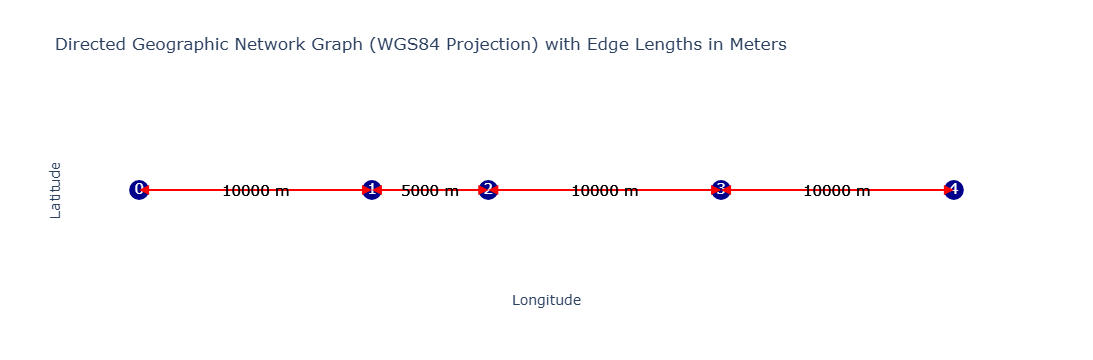

In [6]:
plot_graph(FG)



In [7]:
# add a resource to the graph. make sure to add the same resource to all edges, if you want to create one segment with restriction
resource = simpy.Resource(env, 1)
FG.edges[('1', '2')]["Resources"] = resource
FG.edges[('2', '1')]["Resources"] = resource
FG.edges[('2', '3')]["Resources"] = resource
FG.edges[('3', '2')]["Resources"] = resource
FG.nodes['1']["Resources"] = resource
FG.nodes['2']["Resources"] = resource

In [8]:
env.graph = FG

#### 2. Create vessel
We create three identical vessels

In [9]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        Identifiable, # allows to give the object a name and a random ID,
        Movable,      # allows the object to move, with a fixed speed, while logging this activity
    ), 
)

In [10]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [11]:

# create vessel from dict 
data_vessel = {
    "env": env,                                     # needed for simpy simulation, left empty for now
    "name": "Vessel",                               # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],   # required by Locatable, left empty for now
    "route": nx.dijkstra_path(env.graph, "0", "4"), # required by Routeable, left empty for now
    "v": 1,                                         # required by Movable, 1 m/s to check if the distance is covered in the expected time
}  
vessel_1 = Vessel(**data_vessel)
vessel_1.name = 'Vessel 1'

vessel_2 = Vessel(**data_vessel)
vessel_2.name = 'Vessel 2'

data_vessel_inverse_route = {
    "env": env,                                     # needed for simpy simulation, left empty for now
    "name": "Vessel",                               # required by Identifiable
    "geometry": env.graph.nodes['4']['geometry'],   # required by Locatable, left empty for now
    "route": nx.dijkstra_path(env.graph, "4", "0"), # required by Routeable, left empty for now
    "v": 1,                                         # required by Movable, 1 m/s to check if the distance is covered in the expected time
}  

vessel_3 = Vessel(**data_vessel_inverse_route)  # create a vessel with the same geometry as node 4
vessel_3.name = 'Vessel 3'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.process(mission(env, vessel_3))

<Process(mission) object at 0x23597930b90>

#### 3. Run simulation

In [12]:
# start the simulation
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [13]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0.0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 02:46:40,10000.0,POINT (0.0898315284119522 0)
2,Sailing from node 1 to node 2 start,2024-01-01 02:46:40,10000.0,POINT (0.0898315284119522 0)
3,Sailing from node 1 to node 2 stop,2024-01-01 04:10:00,15000.0,POINT (0.1347472926179282 0)
4,Sailing from node 2 to node 3 start,2024-01-01 04:10:00,15000.0,POINT (0.1347472926179282 0)
5,Sailing from node 2 to node 3 stop,2024-01-01 06:56:40,25000.0,POINT (0.2245788210298804 0)
6,Sailing from node 3 to node 4 start,2024-01-01 06:56:40,25000.0,POINT (0.2245788210298804 0)
7,Sailing from node 3 to node 4 stop,2024-01-01 09:43:20,35000.0,POINT (0.3144103494418325 0)


In [14]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00,0.0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 02:46:40,10000.0,POINT (0.0898315284119522 0)
2,Waiting to pass node 1 start,2024-01-01 02:46:40,10000.0,POINT (0.0898315284119522 0)
3,Waiting to pass node 1 stop,2024-01-01 06:56:40,10000.0,POINT (0.0898315284119522 0)
4,Sailing from node 1 to node 2 start,2024-01-01 06:56:40,10000.0,POINT (0.0898315284119522 0)
5,Sailing from node 1 to node 2 stop,2024-01-01 08:20:00,15000.0,POINT (0.1347472926179282 0)
6,Sailing from node 2 to node 3 start,2024-01-01 08:20:00,15000.0,POINT (0.1347472926179282 0)
7,Sailing from node 2 to node 3 stop,2024-01-01 11:06:40,25000.0,POINT (0.2245788210298804 0)
8,Sailing from node 3 to node 4 start,2024-01-01 11:06:40,25000.0,POINT (0.2245788210298804 0)
9,Sailing from node 3 to node 4 stop,2024-01-01 13:53:20,35000.0,POINT (0.3144103494418325 0)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [15]:
df_eventtable = logbook2eventtable([vessel_1, vessel_2, vessel_3])
df_eventtable

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,ae35328e-6e15-427a-86da-abd5b8923c7f,Vessel 1,Sailing from node 0 to node 1,,POINT (0 0),POINT (0.0898315284119522 0),2024-01-01 00:00:00,2024-01-01 02:46:40,10000.0,10000.0
1,ae35328e-6e15-427a-86da-abd5b8923c7f,Vessel 1,Sailing from node 1 to node 2,,POINT (0.0898315284119522 0),POINT (0.1347472926179282 0),2024-01-01 02:46:40,2024-01-01 04:10:00,5000.0,5000.0
2,ae35328e-6e15-427a-86da-abd5b8923c7f,Vessel 1,Sailing from node 2 to node 3,,POINT (0.1347472926179282 0),POINT (0.2245788210298804 0),2024-01-01 04:10:00,2024-01-01 06:56:40,10000.0,10000.0
3,ae35328e-6e15-427a-86da-abd5b8923c7f,Vessel 1,Sailing from node 3 to node 4,,POINT (0.2245788210298804 0),POINT (0.3144103494418325 0),2024-01-01 06:56:40,2024-01-01 09:43:20,10000.0,10000.0
4,25b93952-11d0-4f6b-b576-e1c7a9c17d49,Vessel 2,Sailing from node 0 to node 1,,POINT (0 0),POINT (0.0898315284119522 0),2024-01-01 00:00:00,2024-01-01 02:46:40,10000.0,10000.0
5,25b93952-11d0-4f6b-b576-e1c7a9c17d49,Vessel 2,Waiting to pass node 1,,POINT (0.0898315284119522 0),POINT (0.0898315284119522 0),2024-01-01 02:46:40,2024-01-01 06:56:40,0.0,15000.0
6,25b93952-11d0-4f6b-b576-e1c7a9c17d49,Vessel 2,Sailing from node 1 to node 2,,POINT (0.0898315284119522 0),POINT (0.1347472926179282 0),2024-01-01 06:56:40,2024-01-01 08:20:00,5000.0,5000.0
7,25b93952-11d0-4f6b-b576-e1c7a9c17d49,Vessel 2,Sailing from node 2 to node 3,,POINT (0.1347472926179282 0),POINT (0.2245788210298804 0),2024-01-01 08:20:00,2024-01-01 11:06:40,10000.0,10000.0
8,25b93952-11d0-4f6b-b576-e1c7a9c17d49,Vessel 2,Sailing from node 3 to node 4,,POINT (0.2245788210298804 0),POINT (0.3144103494418325 0),2024-01-01 11:06:40,2024-01-01 13:53:20,10000.0,10000.0
9,2254c34c-5ca2-40ba-94c6-73634c3e52d7,Vessel 3,Sailing from node 4 to node 3,,POINT (0.3144103494418325 0),POINT (0.2245788210298804 0),2024-01-01 00:00:00,2024-01-01 02:46:40,0.0,10000.0


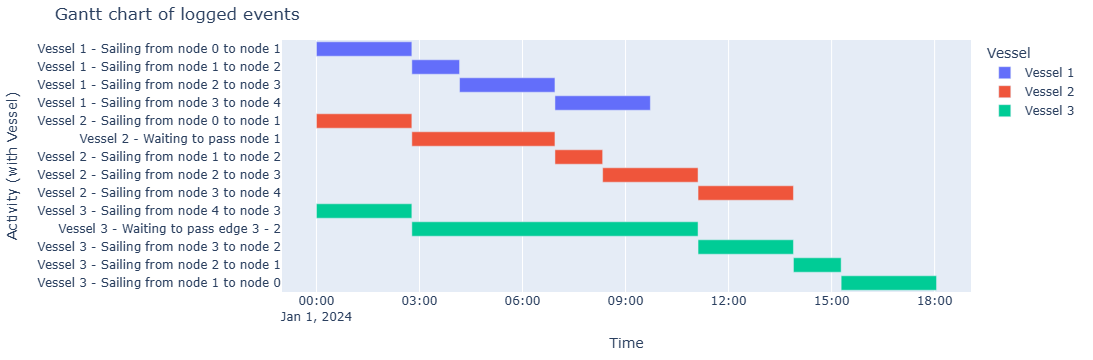

In [16]:
generate_vessel_gantt_chart(df_eventtable)

The inspection of the logbook data shows that vessel 1 can simply sail from node 0 to node 4 in one go. Vessel 2 sails from node 0 to node 1. Vessel 2 has to wait for Vessel1 to give up the resource on nodes 1-3. Once vessel 1 enters edge (3,4), vessel 2 can start sailing onwards form node 1. 
Vessel 3 sails the other way. Vessel 3 has to wait at node 3 for the resource to be available. 